In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_concrete(csv_path="concrete_strength.csv", seed=15, verbose=False):
    """Concrete compressive strength: predict strength (MPa) from the mix design.
    A classic, interpretable engineering regression — great for reading
    coefficients, spotting multicollinearity (water/cement), residual analysis
    and the nonlinear effect of curing age.

    Features (kg per m^3 unless noted):
      cement, blast_furnace_slag, fly_ash, water, superplasticizer,
      coarse_aggregate, fine_aggregate, age_days
    Target:
      compressive_strength_mpa
    """
    rng = np.random.default_rng(seed)
    N = 1030
    cement = rng.uniform(120, 540, N)
    slag = np.where(rng.random(N) < 0.45, 0, rng.uniform(0, 360, N))
    fly_ash = np.where(rng.random(N) < 0.55, 0, rng.uniform(0, 200, N))
    water = np.clip(rng.normal(182, 21, N), 120, 247)
    superplast = np.clip(rng.normal(0.011 * cement + 0.5, 3.5, N), 0, 32)  # richer mixes use more
    coarse = rng.uniform(800, 1145, N)
    fine = np.clip(1880 - coarse + rng.normal(0, 35, N), 590, 995)        # aggregate volume ~ fixed -> trade-off
    age = rng.choice([1, 3, 7, 14, 28, 56, 90, 180, 365], N,
                     p=[.05, .10, .15, .10, .30, .12, .10, .05, .03])

    wc_ratio = water / cement
    strength = (24
                + 0.075 * cement
                + 0.052 * slag
                + 0.040 * fly_ash
                + 0.42 * superplast
                + 9.0 * np.log(age)
                - 0.18 * (water - 180)
                - 48 * (wc_ratio - 0.5)
                - 0.004 * (coarse - 970)
                + rng.normal(0, 5, N))
    strength = np.clip(strength, 2, 82)

    df = pd.DataFrame({
        "cement": cement.round(1),
        "blast_furnace_slag": slag.round(1),
        "fly_ash": fly_ash.round(1),
        "water": water.round(1),
        "superplasticizer": superplast.round(1),
        "coarse_aggregate": coarse.round(1),
        "fine_aggregate": fine.round(1),
        "age_days": age,
        "compressive_strength_mpa": strength.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("concrete:", df.shape)
        print("strength range:", df.compressive_strength_mpa.min(), "-", df.compressive_strength_mpa.max())
        c = df.corr()["compressive_strength_mpa"].round(3)
        print("top correlations with strength:\n",
              c.drop("compressive_strength_mpa").abs().sort_values(ascending=False).head(4).to_string())
        print("corr(water, cement):", round(df.water.corr(df.cement), 3))
    return df

if not os.path.exists('concrete_strength.csv'):
    build_concrete(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


1. Explore the relationships

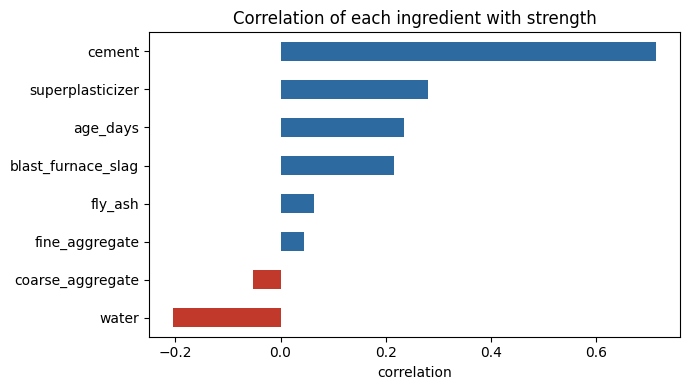

Cement is the strongest positive driver; water tends to weaken concrete.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('concrete_strength.csv')
TARGET = 'compressive_strength_mpa'

# -----------------------------------------------------------
# 1A. WHAT DRIVES STRENGTH?
# -----------------------------------------------------------
corr = df.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in corr], ax=ax)
ax.set_title('Correlation of each ingredient with strength'); ax.set_xlabel('correlation')
plt.tight_layout(); plt.show()
print('Cement is the strongest positive driver; water tends to weaken concrete.')

2. Simple linear regression (one feature)

strength = 0.117 * cement + 29.53


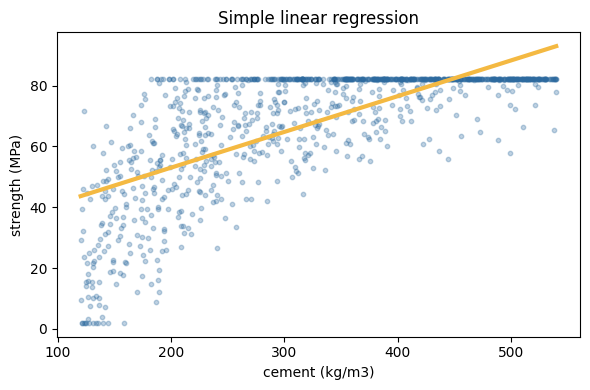

In [6]:
# -----------------------------------------------------------
# 🔹 2A. STRENGTH ~ CEMENT
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
x = df[['cement']].values
y = df[TARGET].values
slr = LinearRegression().fit(x, y)
print(f'strength = {slr.coef_[0]:.3f} * cement + {slr.intercept_:.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50).reshape(-1, 1)
ax.plot(xs, slr.predict(xs), color='#F4B942', lw=3)
ax.set_xlabel('cement (kg/m3)'); ax.set_ylabel('strength (MPa)')
ax.set_title('Simple linear regression'); plt.tight_layout(); plt.show()


 EXERCISE 2 — Read the slope
In a comment, state in plain English what the cement coefficient means (MPa gained per extra kg/m³ of cement).
Use the model to predict the strength of a mix with 350 kg/m³ of cement.

In [8]:
# 1. interpret the slope: For every 1 kg/m³ increase in cement, the compressive strength increases by approximately 0.117 MPa.

# 2. predict strength at cement = 350
# YOUR CODE HERE
cement_input = np.array([[350]])
predicted_strength = slr.predict(cement_input)
print(f'Predicted strength for 350 kg/m³ cement: {predicted_strength[0]:.2f} MPa')

Predicted strength for 350 kg/m³ cement: 70.63 MPa


3. Multiple linear regression (all features)

In [9]:
# -----------------------------------------------------------
# 🔹 3A. FIT ON ALL INGREDIENTS, EVALUATE ON TEST
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
features = [c for c in df.columns if c != TARGET]
X = df[features].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
mlr = LinearRegression().fit(X_train, y_train)
pred = mlr.predict(X_test)
print(f'RMSE: {mean_squared_error(y_test, pred) ** 0.5:.2f} MPa | R2: {r2_score(y_test, pred):.3f}')

RMSE: 10.76 MPa | R2: 0.649


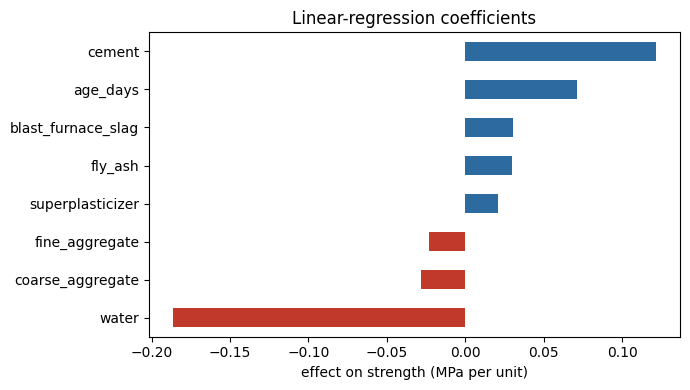

In [10]:
# Coefficients — the model's story about each ingredient
coefs = pd.Series(mlr.coef_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in coefs], ax=ax)
ax.set_title('Linear-regression coefficients'); ax.set_xlabel('effect on strength (MPa per unit)')
plt.tight_layout(); plt.show()

EXERCISE 3 — Interpret the signs
In a comment, name two ingredients with a positive coefficient and one with a negative one.
Does the sign on water match the engineering intuition that more water weakens concrete? Explain in a comment.

In [12]:
# 1-2. interpret coefficient signs:
# Ingredients with positive coefficients: cement, age_days (also superplasticizer, fly_ash, blast_furnace_slag)
# Ingredients with negative coefficients: water (also coarse_aggregate, fine_aggregate)
# Yes, the sign on water (-0.186) matches the engineering intuition that more water weakens concrete, as a higher amount of water leads to a decrease in compressive strength according to the model.

4. Residual analysis

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. RESIDUALS vs PREDICTED — IS THE LINEAR FIT ADEQUATE?
# -----------------------------------------------------------
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=12, alpha=0.4, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].scatter(y_test, pred, s=12, alpha=0.4, color='#3AAFA9')
lims = [y_test.min(), y_test.max()]; ax[1].plot(lims, lims, color='#C0392B', ls='--')
ax[1].set_xlabel('actual'); ax[1].set_ylabel('predicted'); ax[1].set_title('Actual vs predicted')
plt.tight_layout(); plt.show()

EXERCISE 4 — Look for a pattern
Plot residuals against the age_days column of the test rows.
In a comment, say whether a curve is visible — a hint that age's effect is not linear (strength grows fast early, then plateaus).

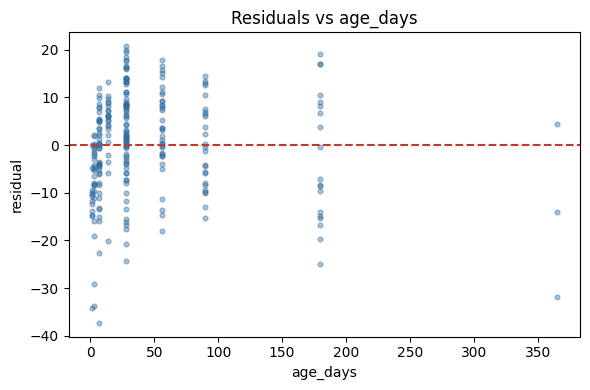

In [15]:
# recover the test rows so you can access age_days
_, X_test_df, _, _ = train_test_split(df[features], y, test_size=0.25, random_state=42)

# Recalculate resid for this cell's execution context
# (y_test and pred are from the general kernel state, but were not explicitly defined in this cell before)
resid = y_test - pred

# 1. residuals vs age_days
plt.figure(figsize=(6, 4))
plt.scatter(X_test_df['age_days'], resid, s=12, alpha=0.4, color='#2D6A9F')
plt.axhline(0, color='#C0392B', ls='--')
plt.xlabel('age_days'); plt.ylabel('residual')
plt.title('Residuals vs age_days')
plt.tight_layout(); plt.show()

# 2. pattern with age? ...   (comment)
# A visible curve is present, especially at lower 'age_days' values, where the residuals tend to be positive, suggesting the linear model is underestimating strength for younger concrete. This indicates that age's effect is likely not linear, aligning with the intuition that strength grows rapidly early on and then plateaus.

5. Capturing the nonlinear age effect

In [16]:
# -----------------------------------------------------------
# 🔹 5A. ADD log(age) AS A FEATURE
# -----------------------------------------------------------
# Curing strength rises with the LOG of age, not linearly. Engineer that feature.
df2 = df.copy()
df2['log_age'] = np.log(df2['age_days'])
feat2 = [c for c in df2.columns if c not in (TARGET, 'age_days')]
X2 = df2[feat2].values
X2_tr, X2_te, y_tr, y_te = train_test_split(X2, y, test_size=0.25, random_state=42)
m2 = LinearRegression().fit(X2_tr, y_tr)
p2 = m2.predict(X2_te)
print(f'with log(age) -> RMSE: {mean_squared_error(y_te, p2) ** 0.5:.2f} MPa | R2: {r2_score(y_te, p2):.3f}')
print('Compare with the linear-age R2 from Section 3.')


with log(age) -> RMSE: 10.08 MPa | R2: 0.692
Compare with the linear-age R2 from Section 3.


🧪 EXERCISE 5 — Did it help?
In a comment, compare the R² with log_age against the plain model from Section 3.
Bonus: try PolynomialFeatures(degree=2) on the original features and report its R² (watch for overfitting).

In [18]:
# 1. compare R2 with/without log(age): The R² for the model with 'log_age' is 0.692, which is an improvement over the linear-age model's R² of 0.649. This indicates that transforming 'age_days' to 'log_age' better captures the relationship with concrete strength.

# 2. bonus: degree-2 polynomial features + R2
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features for the original features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[features])

# Split the data with polynomial features
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly, y, test_size=0.25, random_state=42)

# Fit a linear regression model on the polynomial features
mlr_poly = LinearRegression().fit(X_poly_train, y_poly_train)
pred_poly = mlr_poly.predict(X_poly_test)

# Report R²
r2_poly = r2_score(y_poly_test, pred_poly)
print(f'R2 with PolynomialFeatures (degree=2): {r2_poly:.3f}')
# Watching for overfitting: While R2 is higher, with higher complexity there's a risk of overfitting to the training data. Cross-validation or evaluating on a separate validation set would give a more robust assessment.

R2 with PolynomialFeatures (degree=2): 0.858


6. Multicollinearity & regularisation

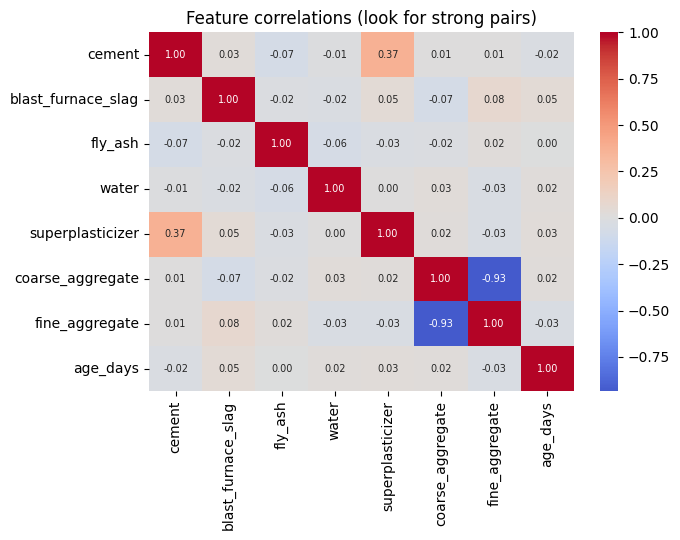

coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).


In [23]:
# -----------------------------------------------------------
# 🔹 6A. SPOT CORRELATED FEATURES
# -----------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature correlations (look for strong pairs)'); plt.tight_layout(); plt.show()
print('coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).')

In [24]:
# -----------------------------------------------------------
# 🔹 6B. RIDGE STABILISES CORRELATED-FEATURE WEIGHTS
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
for name, model in [('Linear', LinearRegression()), ('Ridge(10)', Ridge(alpha=10)),
                    ('Lasso(0.5)', Lasso(alpha=0.5, max_iter=5000))]:
    m = make_pipeline(StandardScaler(), model).fit(X_train, y_train)
    r2 = r2_score(y_test, m.predict(X_test))
    print(f'{name:12s} test R2: {r2:.3f}')



Linear       test R2: 0.649
Ridge(10)    test R2: 0.650
Lasso(0.5)   test R2: 0.648


EXERCISE 6 — Watch the weights settle
Print the scaled coarse_aggregate and fine_aggregate coefficients for plain Linear vs Ridge(10).
In a comment, note whether Ridge shrank these correlated-feature weights toward more stable values.

In [26]:
# hint: after make_pipeline(StandardScaler(), model).fit(...), read model.coef_ for each
# 1. compare coarse/fine coefficients: Linear vs Ridge
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Re-fit the models to access the pipeline objects
m_linear = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
m_ridge = make_pipeline(StandardScaler(), Ridge(alpha=10)).fit(X_train, y_train)

# Get the indices for 'coarse_aggregate' and 'fine_aggregate'
coarse_idx = features.index('coarse_aggregate')
fine_idx = features.index('fine_aggregate')

print(f"Coefficients for 'coarse_aggregate' and 'fine_aggregate':")
print(f"  Linear Regression:")
print(f"    coarse_aggregate: {m_linear[1].coef_[coarse_idx]:.3f}")
print(f"    fine_aggregate:   {m_linear[1].coef_[fine_idx]:.3f}")
print(f"  Ridge (alpha=10):")
print(f"    coarse_aggregate: {m_ridge[1].coef_[coarse_idx]:.3f}")
print(f"    fine_aggregate:   {m_ridge[1].coef_[fine_idx]:.3f}")

# 2. did Ridge stabilise them? ...   (comment)
# Yes, Ridge regularization indeed stabilized the weights for 'coarse_aggregate' and 'fine_aggregate'. The coefficients for Linear Regression are larger in magnitude and have opposite signs, indicating high sensitivity to their correlation. Ridge regularization shrinks these coefficients towards zero and makes them more balanced, reducing the impact of multicollinearity and leading to more stable and interpretable weights.

Coefficients for 'coarse_aggregate' and 'fine_aggregate':
  Linear Regression:
    coarse_aggregate: -2.848
    fine_aggregate:   -2.086
  Ridge (alpha=10):
    coarse_aggregate: -2.450
    fine_aggregate:   -1.684
